# 02. Análisis Exploratorio de Datos (EDA)

In [1]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
#Captura de datos y visualización de los primeros registros.
url_hr = "https://raw.githubusercontent.com/pplonski/datasets-for-start/refs/heads/master/employee_attrition/HR-Employee-Attrition-All.csv"
df_hr = pd.read_csv(url_hr)
print(df_hr.head())
print(df_hr.shape)

In [5]:
# Guardar el DataFrame en un archivo CSV con validación de la ruta
RUTA_CSV = os.path.join("..", "data", "HR-Employee-Attrition.csv")
if not os.path.exists(os.path.dirname(RUTA_CSV)):
    os.makedirs(os.path.dirname(RUTA_CSV))
    
df_hr.to_csv(RUTA_CSV, index=False)

In [9]:
# Verificación de la información del DataFrame
df_hr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

## 2.1 Revisión de valores faltantes:

In [11]:
# Revisión de valores faltantes
valores_faltantes = df_hr.isnull().sum()
porcentaje_faltantes = (valores_faltantes / len(df_hr)) * 100

resumen_faltantes = pd.DataFrame({
    "valores_faltantes": valores_faltantes,
    "porcentaje (%)": porcentaje_faltantes.round(2)
})
resumen_faltantes = resumen_faltantes[resumen_faltantes["valores_faltantes"] > 0]

if resumen_faltantes.empty:
    print("No se encontraron valores faltantes en ninguna columna.")
else:
    print("Columnas con valores faltantes:")
    print(resumen_faltantes.sort_values("porcentaje (%)", ascending=False))

No se encontraron valores faltantes en ninguna columna.


In [12]:
# Columnas con un unico valor (constantes): no aportan informacion para
# distinguir entre clases, por lo que se descartaran en el preprocesamiento.
columnas_constantes = [c for c in df_hr.columns if df_hr[c].nunique() == 1]
print("Columnas constantes encontradas:", columnas_constantes)
for c in columnas_constantes:
    print(f"  {c}: unico valor = {df_hr[c].unique()}")

Columnas constantes encontradas: ['EmployeeCount', 'Over18', 'StandardHours']
  EmployeeCount: unico valor = [1]
  Over18: unico valor = ['Y']
  StandardHours: unico valor = [80]


## 2.2 Detección de valores atípicos:

In [ ]:
# Detección de valores atípicos.
# Estadisticas descriptivas de variables numericas.
numeric_cols = df_hr.select_dtypes(include="number").columns.tolist()
print(f"Variables numericas disponibles: {numeric_cols}")
print(len(numeric_cols))
df_hr[numeric_cols].describe().round(2)

Variables numericas disponibles: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
26


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.00,1470.00,1470.00,1470.00,1470.0,1470.00,1470.00,1470.00,1470.00,1470.00,...,1470.00,1470.0,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,36.92,802.49,9.19,2.91,1.0,1024.87,2.72,65.89,2.73,2.06,...,2.71,80.0,0.79,11.28,2.80,2.76,7.01,4.23,2.19,4.12
std,9.14,403.51,8.11,1.02,0.0,602.02,1.09,20.33,0.71,1.11,...,1.08,0.0,0.85,7.78,1.29,0.71,6.13,3.62,3.22,3.57
min,18.00,102.00,1.00,1.00,1.0,1.00,1.00,30.00,1.00,1.00,...,1.00,80.0,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
25%,30.00,465.00,2.00,2.00,1.0,491.25,2.00,48.00,2.00,1.00,...,2.00,80.0,0.00,6.00,2.00,2.00,3.00,2.00,0.00,2.00
50%,36.00,802.00,7.00,3.00,1.0,1020.50,3.00,66.00,3.00,2.00,...,3.00,80.0,1.00,10.00,3.00,3.00,5.00,3.00,1.00,3.00
75%,43.00,1157.00,14.00,4.00,1.0,1555.75,4.00,83.75,3.00,3.00,...,4.00,80.0,1.00,15.00,3.00,3.00,9.00,7.00,3.00,7.00
max,60.00,1499.00,29.00,5.00,1.0,2068.00,4.00,100.00,4.00,5.00,...,4.00,80.0,3.00,40.00,6.00,4.00,40.00,18.00,15.00,17.00


In [14]:
# Método estadístico 1: IQR (rango intercuartílico)
resumen_outliers_iqr = []
for col in numeric_cols:
    q1 = df_hr[col].quantile(0.25)
    q3 = df_hr[col].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    outliers = df_hr[(df_hr[col] < limite_inferior) | (df_hr[col] > limite_superior)]
    resumen_outliers_iqr.append({
        "columna": col,
        "outliers_iqr": len(outliers),
        "porcentaje (%)": round(100 * len(outliers) / len(df_hr), 2)
    })
    
resumen_outliers_iqr = pd.DataFrame(resumen_outliers_iqr).sort_values(
    "outliers_iqr", ascending=False
)
print("Outliers detectados por IQR:")
print(resumen_outliers_iqr[resumen_outliers_iqr["outliers_iqr"] > 0])

Outliers detectados por IQR:
                    columna  outliers_iqr  porcentaje (%)
20    TrainingTimesLastYear           238           16.19
15        PerformanceRating           226           15.37
11            MonthlyIncome           114            7.76
24  YearsSinceLastPromotion           107            7.28
22           YearsAtCompany           104            7.07
18         StockOptionLevel            85            5.78
19        TotalWorkingYears            63            4.29
13       NumCompaniesWorked            52            3.54
23       YearsInCurrentRole            21            1.43
25     YearsWithCurrManager            14            0.95


In [15]:
# Método estadístico 2: Z-score
z_scores = (df_hr[numeric_cols] - df_hr[numeric_cols].mean()) / df_hr[numeric_cols].std()
outliers_zscore = (z_scores.abs() > 3).sum()
print("\nOutliers detectados por Z-score (|z| > 3):")
print(outliers_zscore[outliers_zscore > 0])


Outliers detectados por Z-score (|z| > 3):
TotalWorkingYears          16
YearsAtCompany             25
YearsInCurrentRole         13
YearsSinceLastPromotion    42
YearsWithCurrManager       14
dtype: int64


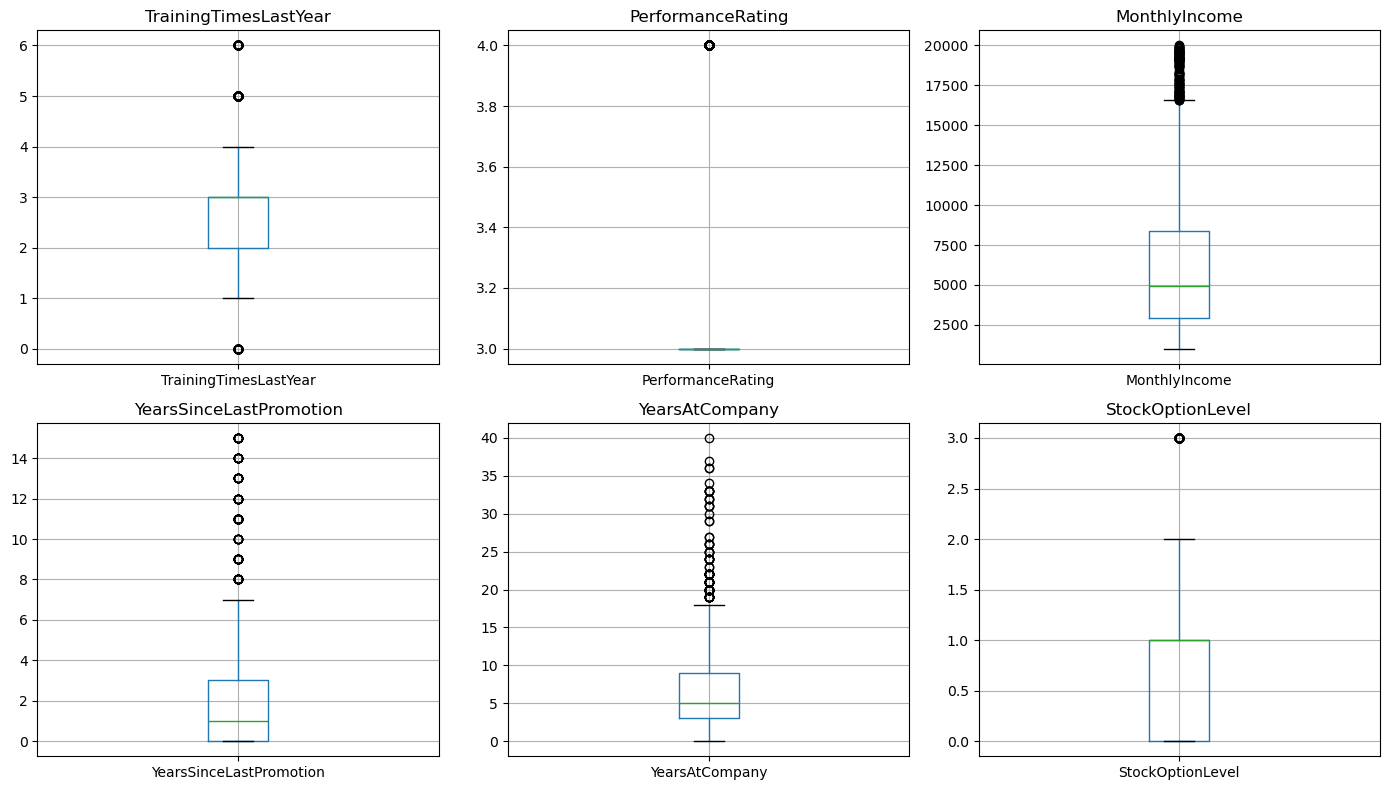

In [16]:
# Método gráfico: boxplots de las variables con más valores atípicos IQR
columnas_a_graficar = resumen_outliers_iqr.head(6)["columna"].tolist()
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flatten(), columnas_a_graficar):
    df_hr.boxplot(column=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig("boxplots_outliers.png", dpi=120)
plt.show()

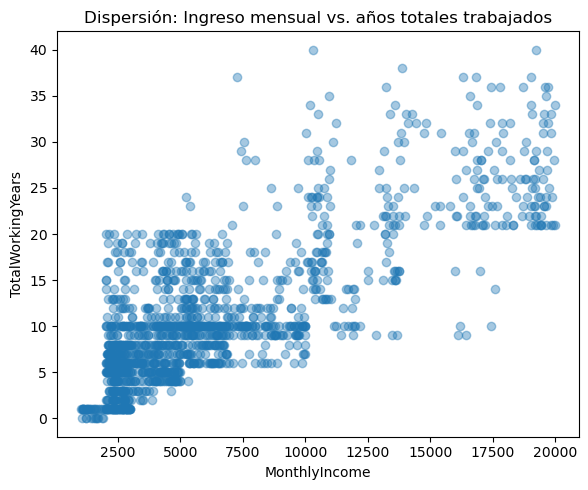

In [17]:
# Método gráfico: dispersión entre dos variables clave
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(df_hr["MonthlyIncome"], df_hr["TotalWorkingYears"], alpha=0.4)
ax.set_xlabel("MonthlyIncome")
ax.set_ylabel("TotalWorkingYears")
ax.set_title("Dispersión: Ingreso mensual vs. años totales trabajados")
plt.tight_layout()
plt.savefig("dispersion_income_vs_years.png", dpi=120)
plt.show()

## 2.3 # Análisis de distribuciones (histogramas + densidad)


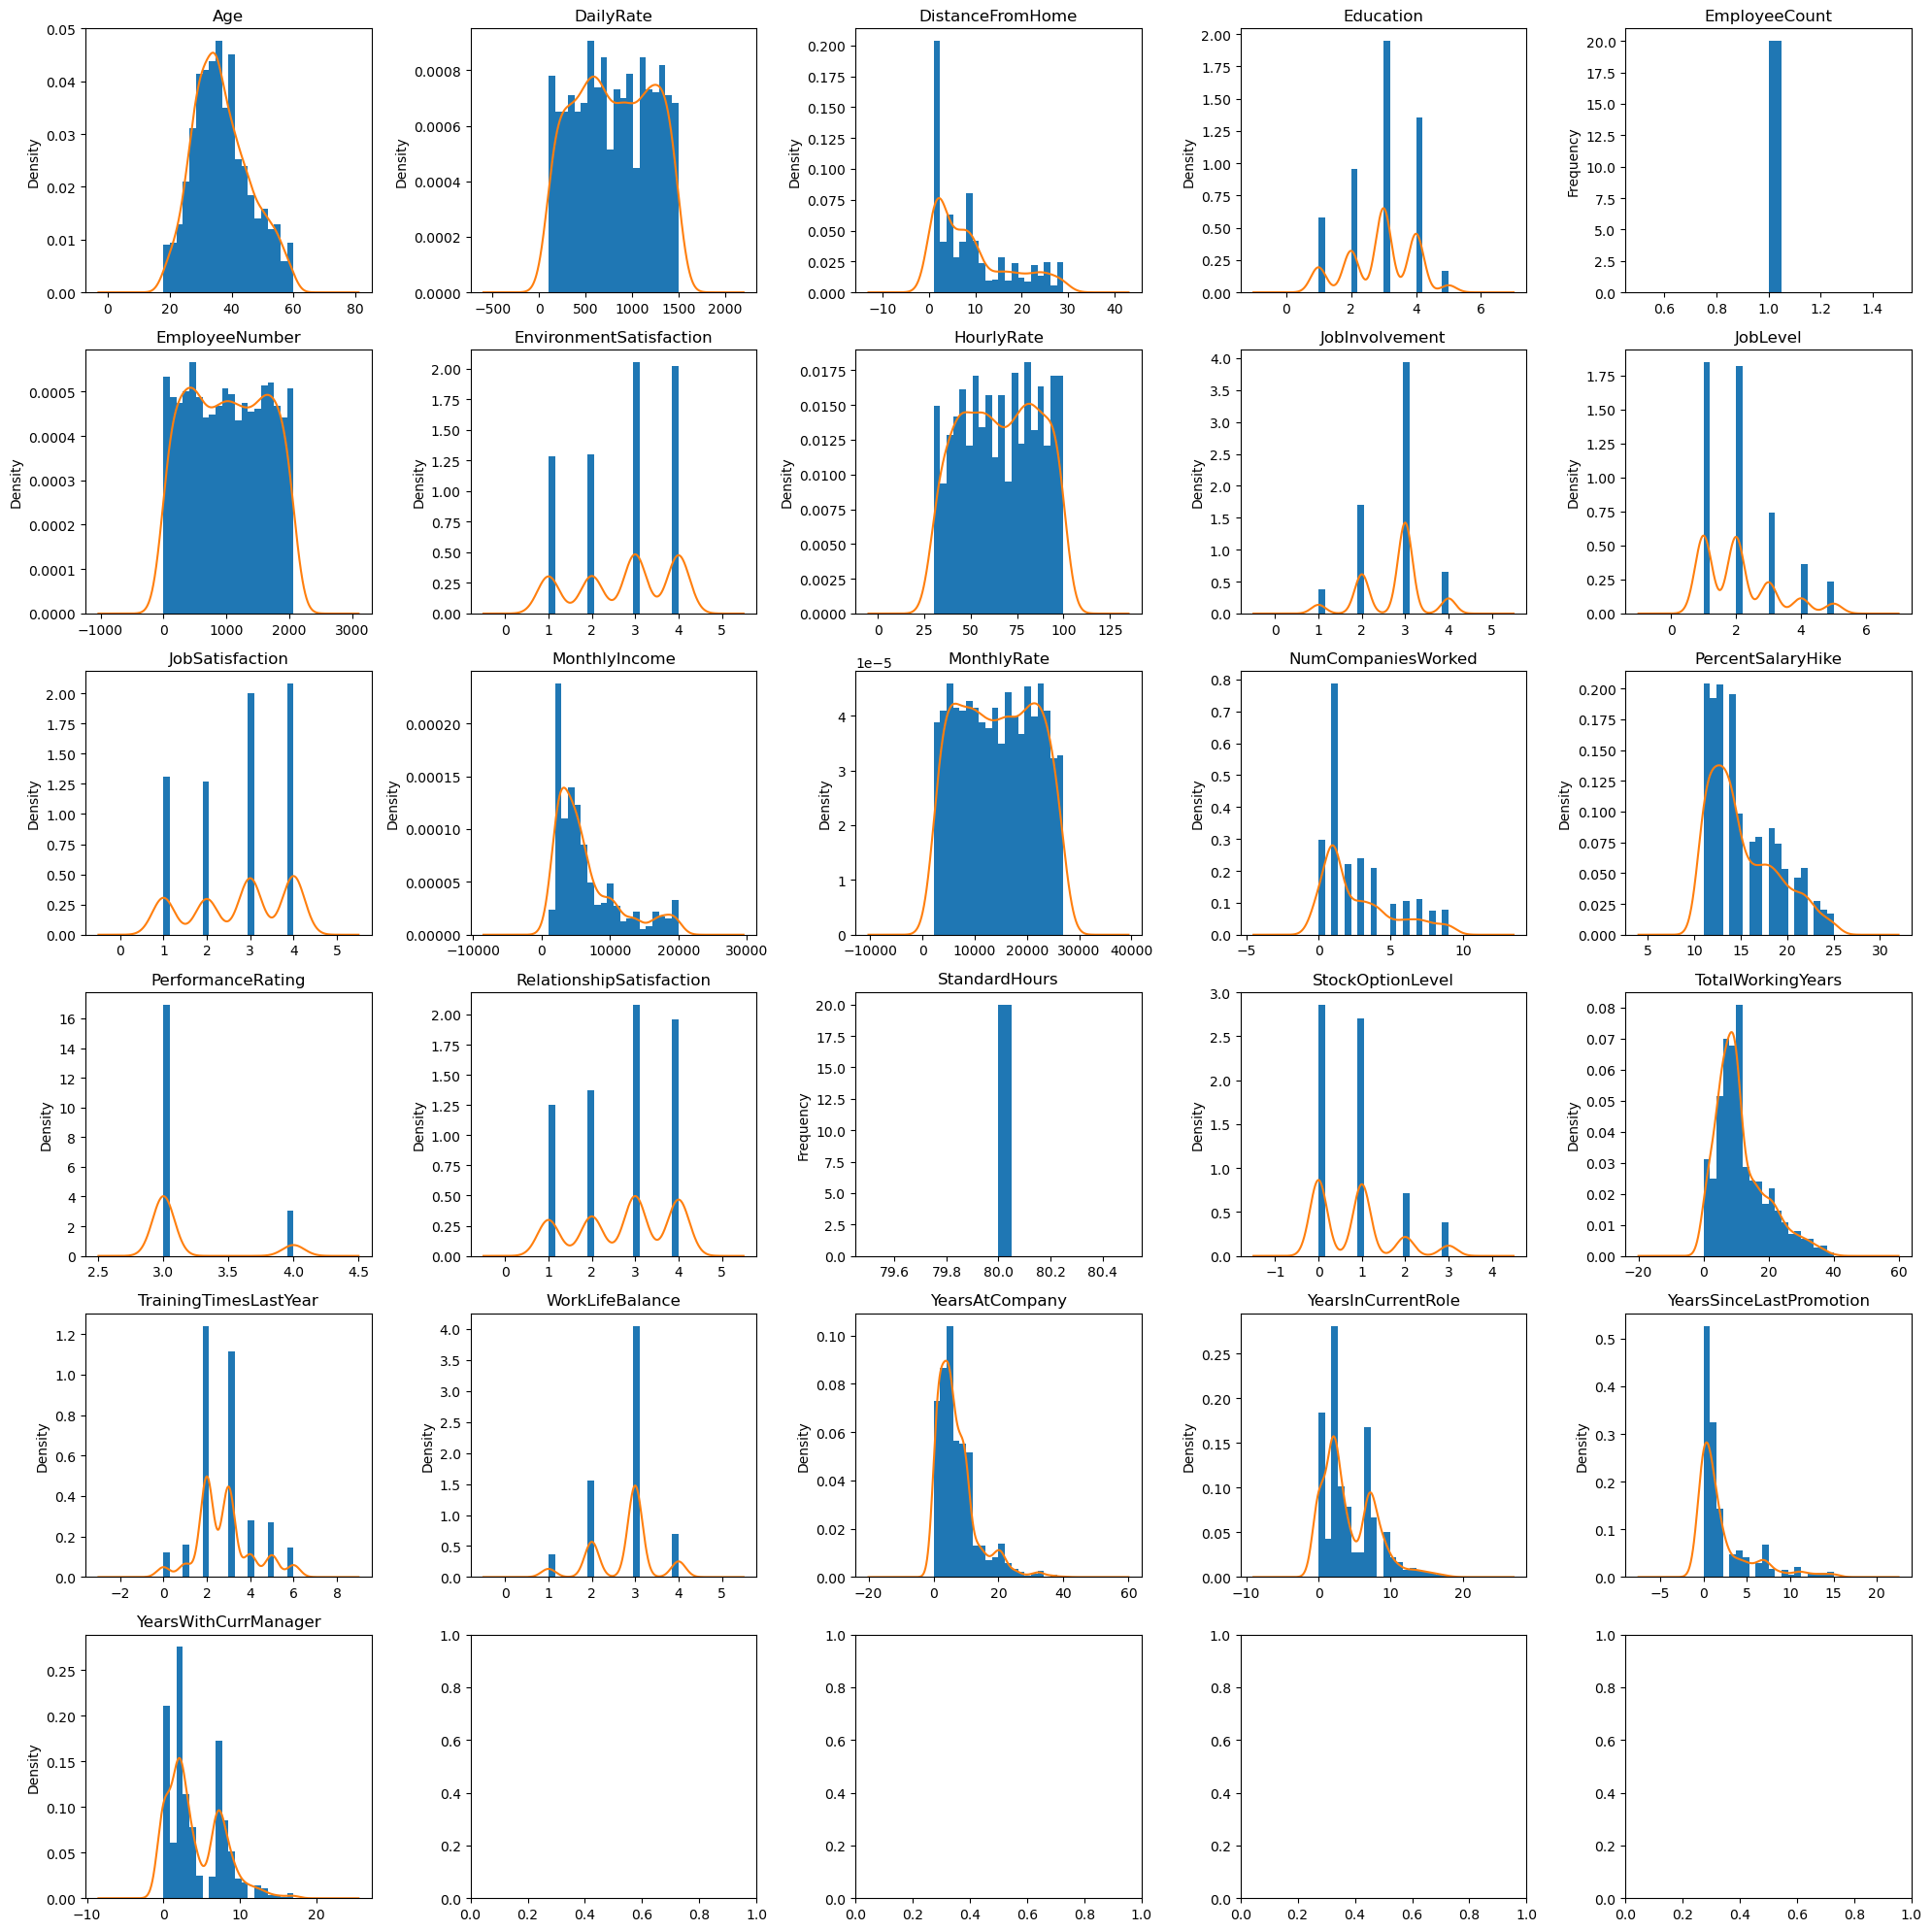

Age                         0.413286
DailyRate                  -0.003519
DistanceFromHome            0.958118
Education                  -0.289681
EmployeeCount               0.000000
EmployeeNumber              0.016574
EnvironmentSatisfaction    -0.321654
HourlyRate                 -0.032311
JobInvolvement             -0.498419
JobLevel                    1.025401
JobSatisfaction            -0.329672
MonthlyIncome               1.369817
MonthlyRate                 0.018578
NumCompaniesWorked          1.026471
PercentSalaryHike           0.821128
PerformanceRating           1.921883
RelationshipSatisfaction   -0.302828
StandardHours               0.000000
StockOptionLevel            0.968980
TotalWorkingYears           1.117172
TrainingTimesLastYear       0.553124
WorkLifeBalance            -0.552480
YearsAtCompany              1.764529
YearsInCurrentRole          0.917363
YearsSinceLastPromotion     1.984290
YearsWithCurrManager        0.833451
dtype: float64


In [28]:
# Análisis de distribuciones: histograma + densidad
columnas_numericas = df_hr.select_dtypes(include=np.number).columns
fig, axes = plt.subplots(nrows=6, ncols=5, figsize=(20, 20))
axes = axes.flatten()

for ax, col in zip(axes, columnas_numericas):
    df_hr[col].plot(kind="hist", bins=20, density=True, ax=ax, title=col)
    if df_hr[col].std() > 0:
        df_hr[col].plot(kind="kde", ax=ax)

plt.tight_layout()
plt.show()

# Sesgo de cada variable (se identifica posibles transformaciones necesarias)
print(df_hr[columnas_numericas].skew())

## 2.4 Análisis univariado: variables numéricas y categóricas por separado

               Age    DailyRate  DistanceFromHome    Education  EmployeeCount  \
count  1470.000000  1470.000000       1470.000000  1470.000000         1470.0   
mean     36.923810   802.485714          9.192517     2.912925            1.0   
std       9.135373   403.509100          8.106864     1.024165            0.0   
min      18.000000   102.000000          1.000000     1.000000            1.0   
25%      30.000000   465.000000          2.000000     2.000000            1.0   
50%      36.000000   802.000000          7.000000     3.000000            1.0   
75%      43.000000  1157.000000         14.000000     4.000000            1.0   
max      60.000000  1499.000000         29.000000     5.000000            1.0   

       EmployeeNumber  EnvironmentSatisfaction   HourlyRate  JobInvolvement  \
count     1470.000000              1470.000000  1470.000000     1470.000000   
mean      1024.865306                 2.721769    65.891156        2.729932   
std        602.024335            

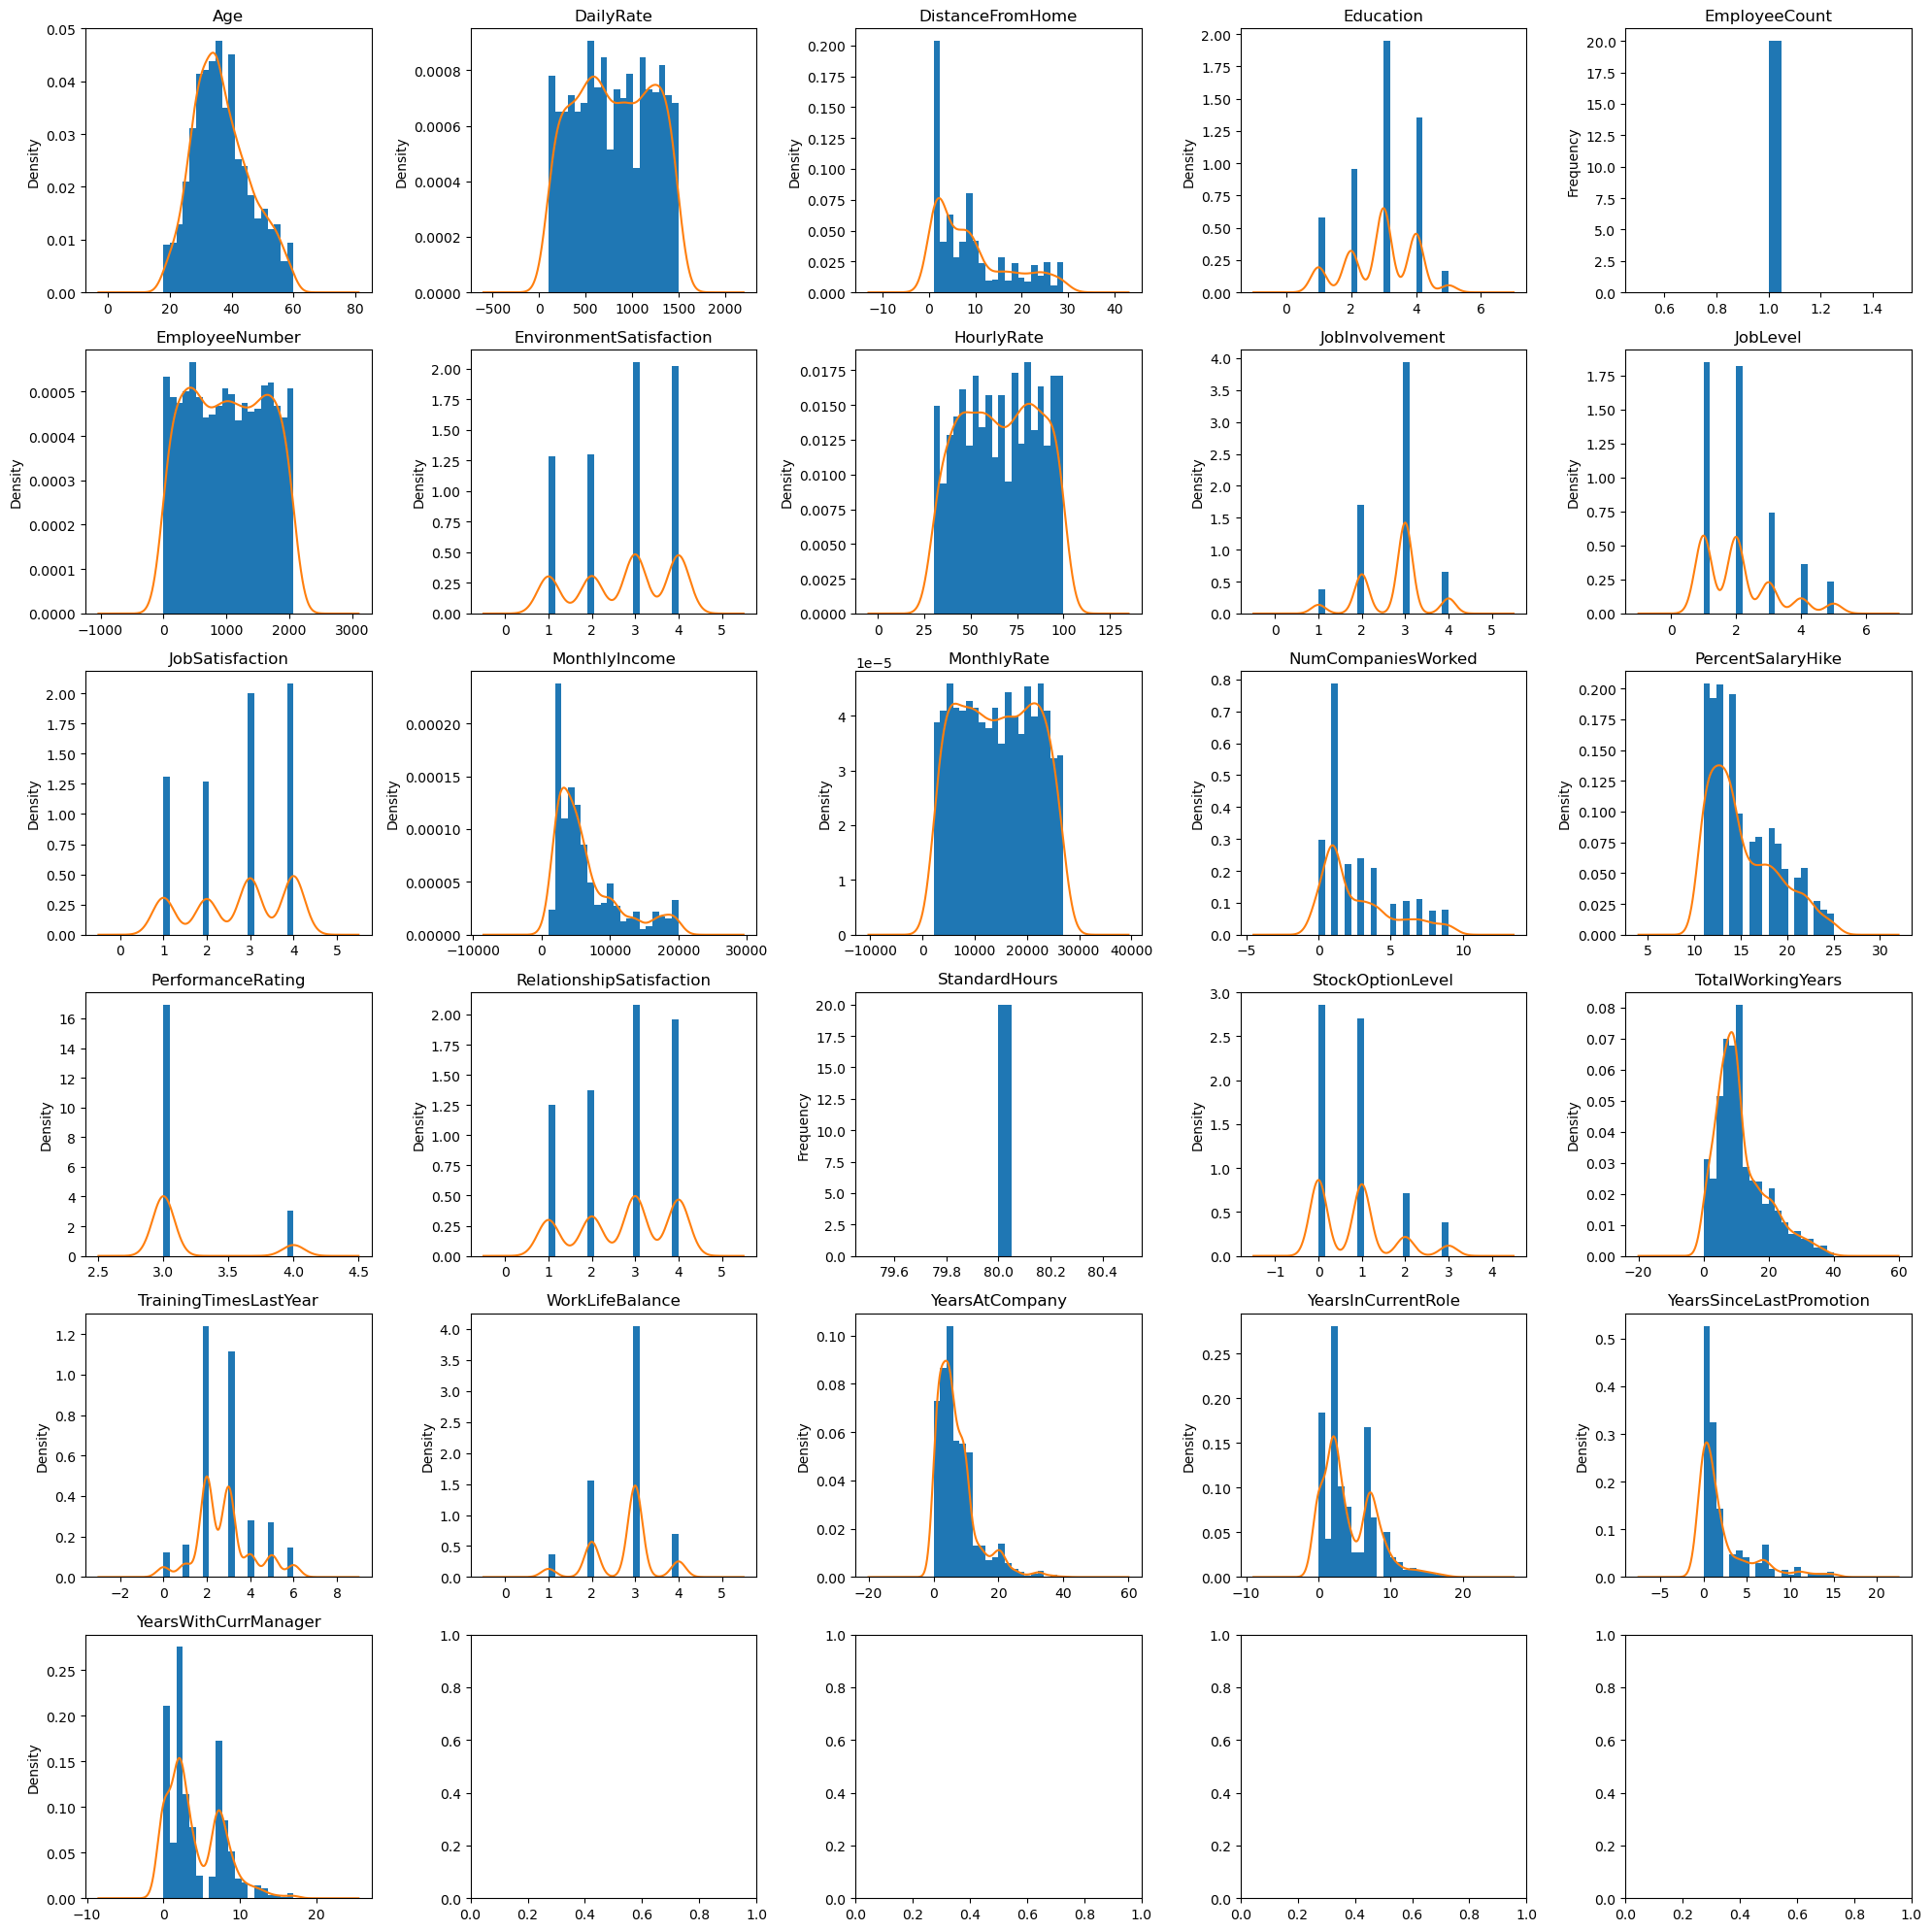

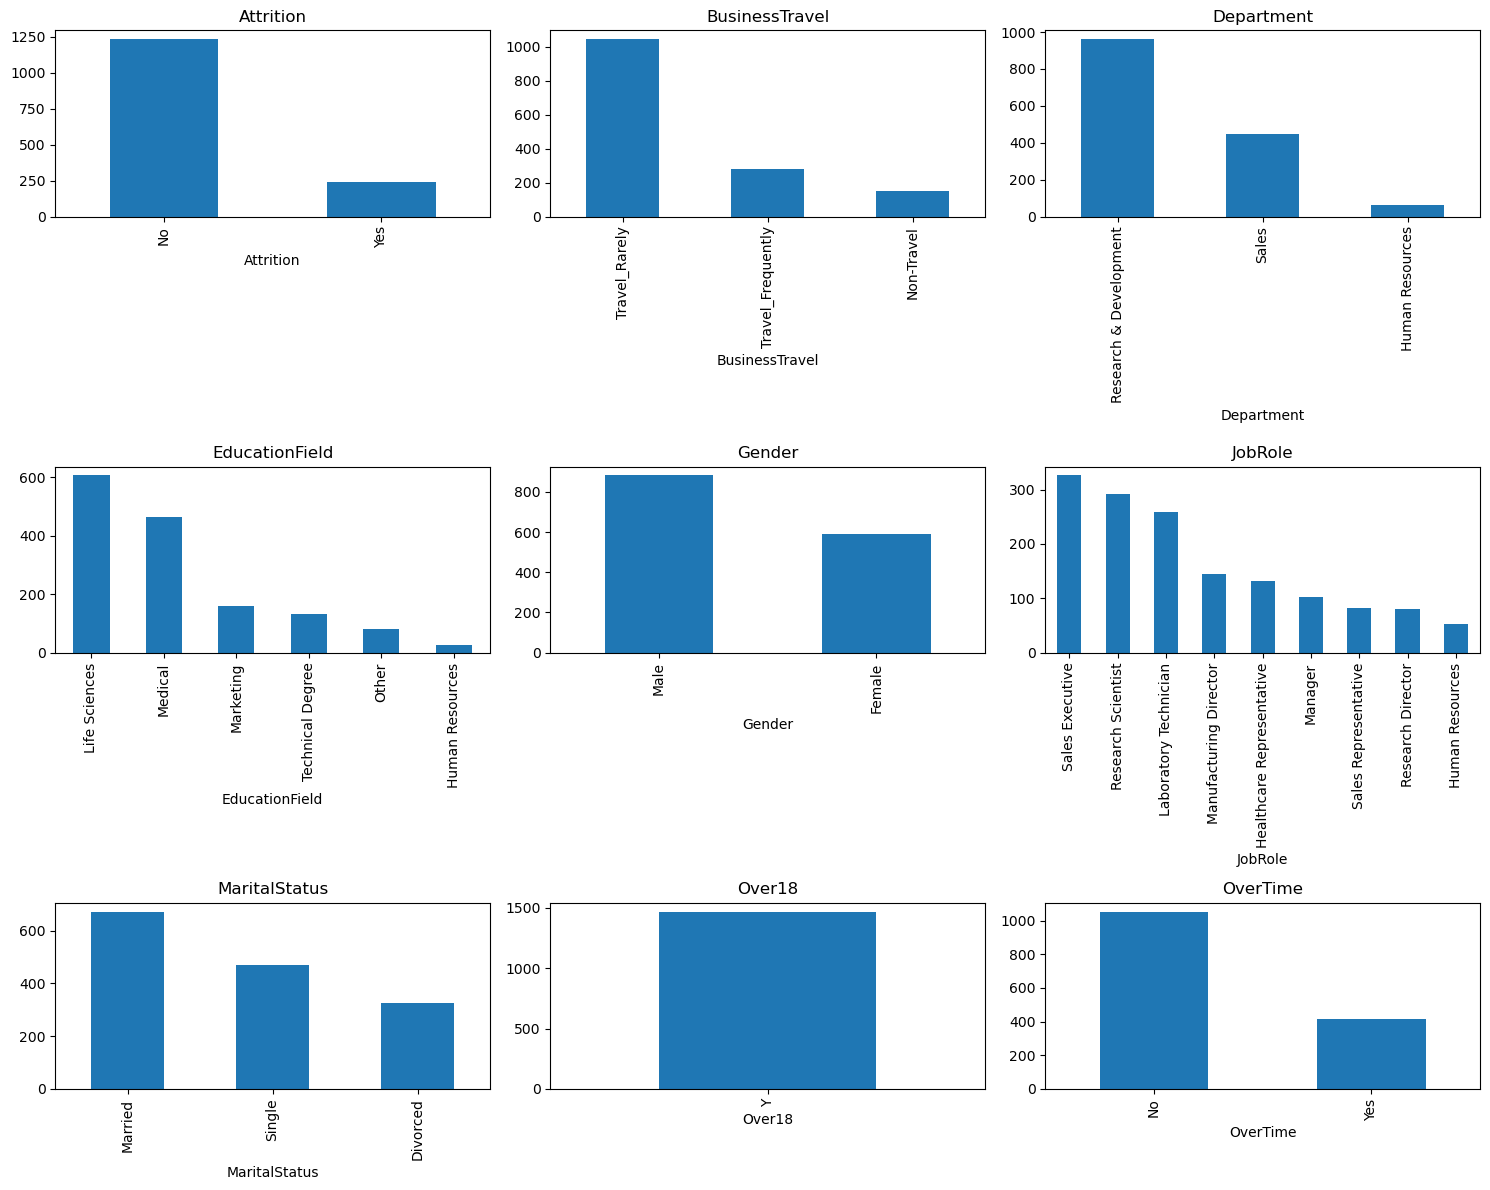

In [ ]:
# Análisis univariado

# Nuevamente vemos estadísticos descriptivos, pero ahora de manera más formal y organizada.
print(df_hr.describe())                  # variables numéricas
print(df_hr.describe(include="object"))  # variables categóricas

# Variables numéricas: histograma + densidad
columnas_numericas = df_hr.select_dtypes(include=np.number).columns
fig, axes = plt.subplots(nrows=6, ncols=5, figsize=(20, 20))
axes = axes.flatten()

for ax, col in zip(axes, columnas_numericas):
    df_hr[col].plot(kind="hist", bins=20, density=True, ax=ax, title=col)
    if df_hr[col].std() > 0:
        df_hr[col].plot(kind="kde", ax=ax)

plt.tight_layout()
plt.show()

# Variables categóricas: gráfico de barras.
columnas_categoricas = df_hr.select_dtypes(include="object").columns
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()

for ax, col in zip(axes, columnas_categoricas):
    df_hr[col].value_counts().plot(kind="bar", ax=ax, title=col)

plt.tight_layout()
plt.show()